In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing()
x, y = housing.data, housing.target

# Split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Scale the data using StandardScaler
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
x_test_s = scaler.transform(x_test)

# Initialize and train RandomForestRegressor for regression task, enabling OOB score
rf = RandomForestRegressor(n_estimators=100, oob_score=True, random_state=42)
rf.fit(x_train_s, y_train)

# Make predictions and evaluate using regression metrics
preds_rf = rf.predict(x_test_s)
print(f'Random Forest MSE: {mean_squared_error(y_test, preds_rf):.2f}')
print(f'Random Forest R2: {r2_score(y_test, preds_rf):.2f}')
print(f'Random Forest OOB Score: {rf.oob_score_:.2f}')

# Get feature importances and print top features using housing dataset feature names
idx = np.argsort(rf.feature_importances_)[::-1]
print('Top features:', [housing.feature_names[i] for i in idx[:2]])

Random Forest MSE: 0.26
Random Forest R2: 0.81
Random Forest OOB Score: 0.81
Top features: ['MedInc', 'AveOccup']


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

pipe = Pipeline(steps=[('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=200, random_state=42))])
pipe.fit(x_train, y_train)
print('Accuracy:',accuracy_score(y_test, pipe.predict(x_test)))
print('Steps:',pipe.steps)

Accuracy: 1.0
Steps: [('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=200, random_state=42))]


In [11]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris
import numpy as np

iris = load_iris()
x, y = iris.data, iris.target
pipe = Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=200, random_state=42))])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, x, y, cv=cv, scoring='accuracy')
print('Fold scores:', scores.round(2))
print(f'Mean:{scores.mean():.2f}  Std: {scores.std():.3f}')

Fold scores: [1.   0.97 0.9  1.   0.9 ]
Mean:0.95  Std: 0.045


In [13]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.datasets import load_iris

iris = load_iris()
x, y = iris.data, iris.target
x_train_s, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
pipe = Pipeline([('scaler', StandardScaler()), ('model', SVC())])
param_grid = {'model__kernel': ['linear', 'rbf'],
              'model__C': [0.1, 1, 10]}
grid = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')
grid.fit(x_train_s, y_train)
print('Best params:', grid.best_params_)
print('Best CV acc:', round(grid.best_score_, 2))
print('Test accuracy:', round(grid.score(x_test, y_test), 2))

Best params: {'model__C': 0.1, 'model__kernel': 'linear'}
Best CV acc: 0.96
Test accuracy: 1.0


AUC Score: 1.00


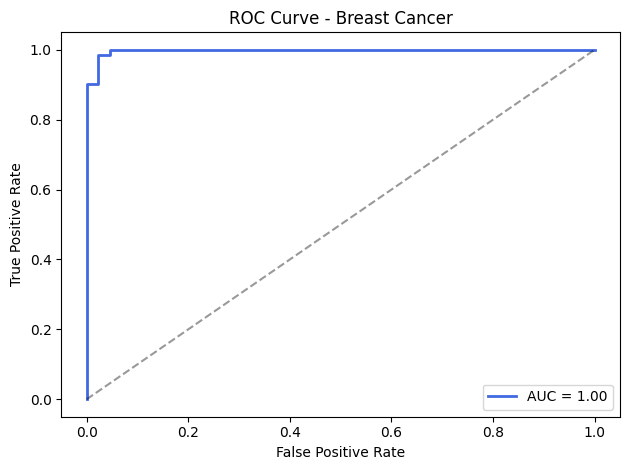

In [15]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

x, y = load_breast_cancer(return_X_y=True)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
pipe = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(random_state=42))])
pipe.fit(x_train, y_train)
proba = pipe.predict_proba(x_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
print(f'AUC Score: {auc:.2f}')
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.2f}', color='royalblue', linewidth=2)
plt.plot([0,1], [0,1], 'k--', alpha=0.4)
plt.title('ROC Curve - Breast Cancer') ; plt.xlabel('False Positive Rate') ; plt.ylabel('True Positive Rate')
plt.legend() ; plt.tight_layout()
plt.savefig('sklearn_roc.png', dpi=100) ; plt.show()

Logistic Regression    : 0.95 +/- 0.05
KNN (k=5)              : 0.97 +/- 0.02
Decision Tree          : 0.95 +/- 0.03
Random Forest          : 0.95 +/- 0.03


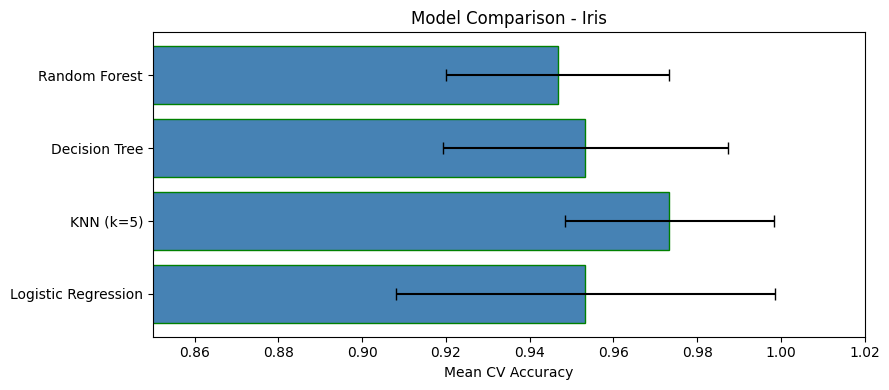

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.datasets import load_iris
import numpy as np, matplotlib.pyplot as plt

iris = load_iris()
x = iris.data
y = iris.target
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
models = {'Logistic Regression' : LogisticRegression(max_iter=200, random_state=42),
          'KNN (k=5)'           : KNeighborsClassifier(n_neighbors=5),
          'Decision Tree'       : DecisionTreeClassifier(max_depth=4, random_state=42),
          'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42)}

means, stds, names = [], [], []
for name, model in models.items():
    pipe = Pipeline([('sc', StandardScaler()), ('m', model)])
    scores = cross_val_score(pipe, x, y, cv=cv, scoring='accuracy')
    means.append(scores.mean())
    stds.append(scores.std())
    names.append(name)
    print(f'{name:<22} : {scores.mean():.2f} +/- {scores.std():.2f}')
plt.figure(figsize=(9, 4))
plt.barh(names, means, xerr=stds, color='steelblue', edgecolor='green', capsize=4)
plt.xlabel('Mean CV Accuracy')
plt.title('Model Comparison - Iris')
plt.xlim(0.85, 1.02)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=100)
plt.show()